# PROJEKT KONCOWY

In [2]:
# data manipulation
import numpy as np
import pandas as pd
import datetime as dt
import time
from math import sqrt
from tqdm import tqdm


# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection
from sklearn.feature_selection import RFECV

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# optimization and hyperparameters
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# model evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer

# interpretowalność modelu
import shap
shap.initjs()

# zapisanie modelu
import joblib

# settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'shap'

# 1. zrozumienie uwarunkowan biznesowych

Innymi słowy – zrozumienie problemu! Możemy przecież wykorzystywać analizę danych i techniki uczenia maszynowego w różnych dziedzinach – geodezji, farmacji, ekonomii itd. W tej części musimy się dowiedzieć – na jakie pytanie ma nam odpowiadać model, jak obecnie jest rozwiązywany problem, jakie informacje wykorzystują specjaliści z tego zakresu oraz czy jest możliwe zastosowanie uczenia maszynowego w tym konkretnym przypadku. Przejdźmy do naszego problemu, który mamy do rozwiązania!

Załóżmy, że pracujemy w dziale badań i rozwoju firmy wypożyczającej rowery. Obecnie firma przygotowuje na swoich stanowiskach tyle rowerów, jaka była średnia z wypożyczonych jednośladów w poprzednim tygodniu oraz w poprzednim roku.

Niewystarczająca liczba rowerów na stanowiskach to utracony zysk o wartości 10zł, taki bowiem jest średni zysk z wypożyczenia jednego roweru na tej trasie.

Jeśli zbyt wiele rowerów jest na stanowisku, to utrzymujemy rowery, które nie przynoszą zysku, a wcześniej musieliśmy je przywieźć – średni dzienny koszt, który ponosimy przez niewypożyczenie roweru to 1zł.

Procesy logistyczne w nasze firmie działają z tygodniowym wyprzedzeniem. W związku z tym prognozę robimy na następny tydzień. To znaczy po skończonym poniedziałku (czyli wiemy ile wypożyczono rowerów tego dnia) robimy prognozę na poniedziałek w następnym tygodniu. To nic innego, jak uwarunkowania biznesowe.

## 2. Zrozumienie Danych

Ten etap często jest źle zrozumiany przez mniej doświadczonych badaczy, którzy sprawdzają rozkłady/korelacje i inne rzeczy, kopiują z kursów i nic za tym nie idzie. W tej części powinniśmy odpowiedzieć sobie na pytanie, które zmienne mają wpływ na naszą zmienną objaśnianą (y) oraz jakie kroki powinniśmy dalej wykonać:

- czy któraś zmienna jest wyciekiem danych i powinna być usunięta,
- czy są zmienne skorelowane ze sobą i przekazują tę samą informację,
- czy są braki w danych i JAK JE UZUPEŁNIĆ,
- czy są wartości odstające/nieprawdziwe i jak/czy powinniśmy je zamienić,
- jak przekształcić dane aby, model miał „łatwiej”.

Podsumowując – po tym kroku powinniśmy wiedzieć, co mamy robić w kolejnym kroku (Przygotowanie danych).

In [3]:
dataframe = pd.read_csv('bikerides_day.csv')
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe

,Date,Volume,Rain,Temp
0,2016-11-17,933.0,9.0,2.1
1,2016-11-18,1197.0,6.7,3.9
2,2016-11-19,243.0,5.4,2.0
3,2016-11-20,234.0,3.9,2.8
4,2016-11-21,2148.0,7.3,2.8
...,...,...,...,...
1268,2020-05-16,2484.0,0.0,6.6
1269,2020-05-17,1509.0,0.0,9.1
1270,2020-05-18,5775.0,0.0,9.3
1271,2020-05-19,6741.0,0.0,9.7


Mamy dane czasowe o częstotliwości dziennej i dla każdego dnia mamy liczbę rowerzystów oraz dane pogodowe w tych dniach, którymi są opady oraz temperatura. Zakładamy, że w przyszłości pogoda zapowiada się idealnie. Teraz odpowiedzmy sobie na kilka pytań, które pomogą nam w przygotowaniu danych.

# Czy sa brakujace wartosci?

In [4]:
dataframe.isnull().mean()*100


Date      0.0
Volume    0.0
Rain      0.0
Temp      0.0
dtype: float64

Ten kod oblicza procent brakujących wartości (NaN) w każdej kolumnie DataFrame’u:
dataframe.isnull().mean() * 100

- isnull() – zamienia każdą wartość na True, jeśli jest brakiem (NaN), lub False
- mean() – liczy średnią w każdej kolumnie; True jest traktowane jako 1, a False jako 0
- * 100 – zamienia wynik na procent
 
  
Przykładowy wynik:
wiek        10.0
miasto      25.0
zarobki      0.0
Oznacza to, że w kolumnie wiek brakuje 10% wartości, w miasto 25%, a w zarobki nie ma braków.

Braków nie ma dla indeksów, jednak to nie znaczy, że braków nie ma gdzie indziej. Niejasne? Zaraz stanie się to jasne, takie sprawdzenie nie wystarczy.

# Czy są duplikaty dla daty?

In [5]:
dataframe.loc[dataframe.duplicated(subset='Date', keep=False), :]

,Date,Volume,Rain,Temp


Ten kod wybiera z DataFrame’u wszystkie wiersze, w których wartość kolumny Date występuje więcej niż raz:
dataframe.loc[
    dataframe.duplicated(subset='Date', keep=False),
    :
]
duplicated(subset='Date') – sprawdza duplikaty wyłącznie w kolumnie Date
keep=False – oznacza jako True wszystkie wystąpienia powtarzającej się daty, również pierwsze
.loc[warunek, :] – zwraca wiersze spełniające warunek oraz wszystkie kolumny (:)
Przykład:
Date        Value
2024-01-01  10
2024-01-02  20
2024-01-01  30
Wynik:
Date        Value
2024-01-01  10
2024-01-01  30
Kod jedynie wyświetla duplikaty — nie usuwa ich.

# CZy daty sa posortowane ?

In [6]:
(dataframe['Date'] == dataframe['Date'].sort_values()).all()

True

# Czy Sa wszystkie daty ?

To, że w naszym zbiorze nie ma braków to nie znaczy, że one nie istnieją. Jako że mamy dane czasowe o częstotliwości dziennej, to brakiem będzie brak któregokolwiek dnia z zakresu od najstarszej do najnowszej. Tak, w tym przypadku to będzie brak. Zadaj sobie pytanie, czy wiesz, aby jak to sprawdzić.

By to zrobić, tworzymy zakres wszystkich dat, które powinny się pojawić w zbiorze. Wykorzystujemy funkcję date_range z biblioteki Pandas, podajemy minimalną datę i maksymalną dla niej. Następnie wykorzystujemy metodę difference, aby wskazać, jakich dat brakuje w zbiorze danych.

In [7]:
pd.date_range(start=dataframe['Date'].min(), end=dataframe['Date'].max()).difference(dataframe['Date'])

DatetimeIndex(['2017-10-16', '2019-01-14', '2019-06-07', '2019-06-08',
               '2019-06-09', '2019-06-10', '2019-08-14', '2019-08-15'],
              dtype='datetime64[ns]', freq=None)

Jednak, są brakujące wartości. Sprawdźmy czy jest tak na pewno, spróbujmy wyświetlić pierwszą brakującą wartość.

In [8]:
dataframe.loc[dataframe['Date']=='2017-10-16',:]

,Date,Volume,Rain,Temp


Brak wartości. Sprawdźmy czy wartość jest dla dnia poprzedzającego.

In [9]:
dataframe.loc[dataframe['Date']=='2017-10-15',:]

,Date,Volume,Rain,Temp
332,2017-10-15,843.0,0.0,9.6


To jest właśnie CEL eksploracyjnej analizy danych, znaleźliśmy problem w danych surowych. Wiemy, że mamy brakujące daty, powinniśmy je uzupełnić – szczególnie w zbiorze treningowym, niekoniecznie w zbiorze testowym, ponieważ w tym przypadku będziemy uzupełniać y. Czy wartość średnia lub mediana będzie odpowiednia, aby uzupełnić zmienną objaśnianą y? Spróbuj odpowiedzieć sobie na to pytanie.

najrozsądniej byłoby:
Uzupełnić indeks brakującymi datami, aby zachować ciągłość kalendarza.
Pozostawić dla nich y = NaN.
Nie wykorzystywać tych wierszy podczas uczenia i oceny modelu.
Nie usuwać dat całkowicie, jeżeli tworzysz cechy opóźnione (lag) lub średnie kroczące.
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe = dataframe.set_index('Date').asfreq('D')

training_data = dataframe.dropna(subset=['y'])
Jeżeli jednak zadanie wymaga uzupełnienia y, nie stosowałbym globalnej średniej ani mediany. Lepszym przybliżeniem byłaby mediana dla podobnych dni — np. tego samego miesiąca i dnia tygodnia:


dataframe['month'] = dataframe.index.month
dataframe['weekday'] = dataframe.index.dayofweek

seasonal_median = dataframe.groupby(
    ['month', 'weekday']
)['y'].transform('median')

dataframe['y_imputed'] = dataframe['y'].fillna(seasonal_median)


Trzeba pamiętać, że cztery dni od 7 do 10 czerwca obejmują piątek–poniedziałek, więc zastąpienie ich jedną średnią byłoby szczególnie nietrafione — weekendowe wypożyczenia mogą zachowywać się inaczej niż te w dni robocze.
Do projektu możesz wpisać:
Brakujące daty stanowią około 0,63% obserwacji. Nie są jednak całkowicie losowo rozproszone, ponieważ cztery kolejne braki występują między 7 a 10 czerwca 2019 roku. Uzupełnienie zmiennej objaśnianej globalną średnią lub medianą mogłoby zaburzyć sezonowość oraz różnice między dniami roboczymi i weekendami. Dlatego brakujące daty zostały dodane do osi czasu, ale obserwacje bez znanej wartości y pominięto podczas treningu. Gdyby imputacja była konieczna, należałoby zastosować metodę uwzględniającą co najmniej miesiąc i dzień tygodnia.



14:29

# Jaki jest rozkład naszych danych?

In [10]:
dataframe.describe()

,Date,Volume,Rain,Temp
count,1273,1273.000000,1273.000000,1273.000000
mean,2018-08-17 15:16:15.648075264,2609.344855,1.945640,6.783975
min,2016-11-17 00:00:00,63.000000,0.000000,-11.400000
25%,2017-10-01 00:00:00,1185.000000,0.000000,0.700000
50%,2018-08-16 00:00:00,2073.000000,0.000000,5.500000
75%,2019-07-05 00:00:00,3801.000000,1.400000,13.400000
max,2020-05-20 00:00:00,8679.000000,39.500000,25.900000
std,NaN,1968.623825,4.505151,7.726084


Aby rozszerzyć tę analizę, dodajmy histogramy oraz wykresy pudełkowe dla zmiennych numerycznych (czyli dla wszystkich poza datą).

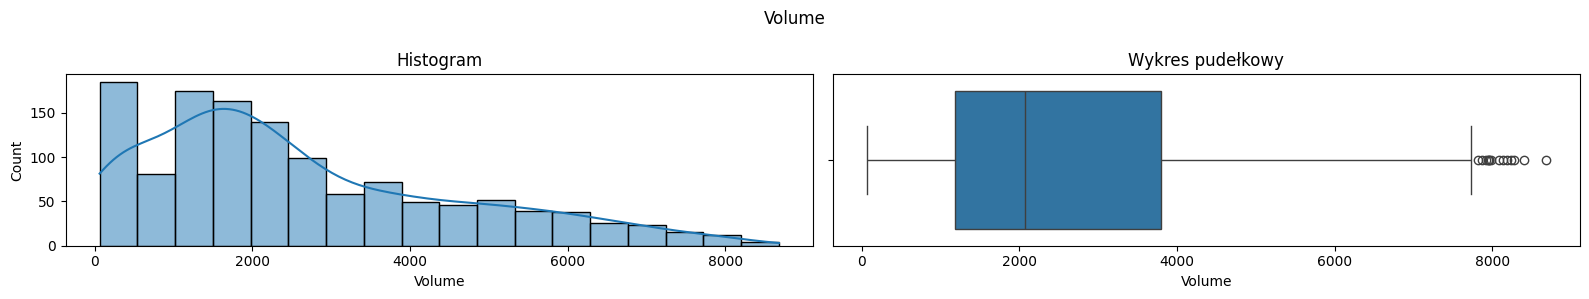

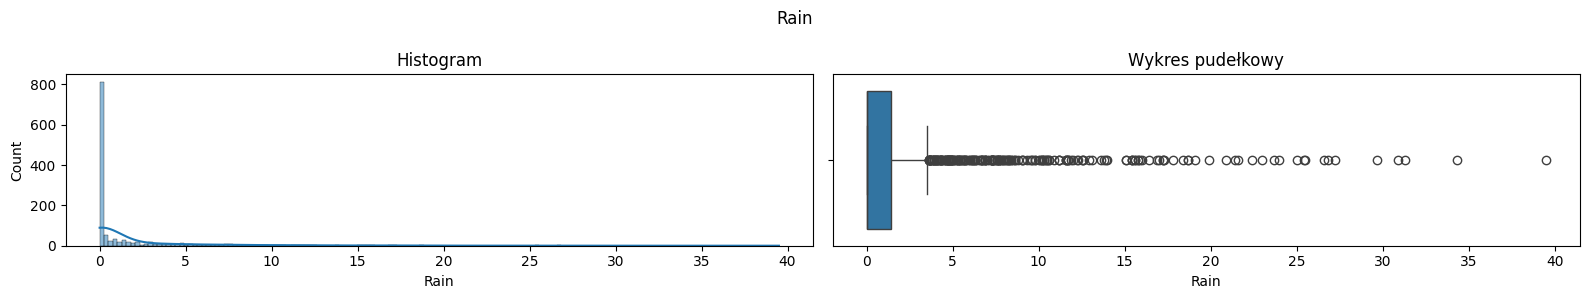

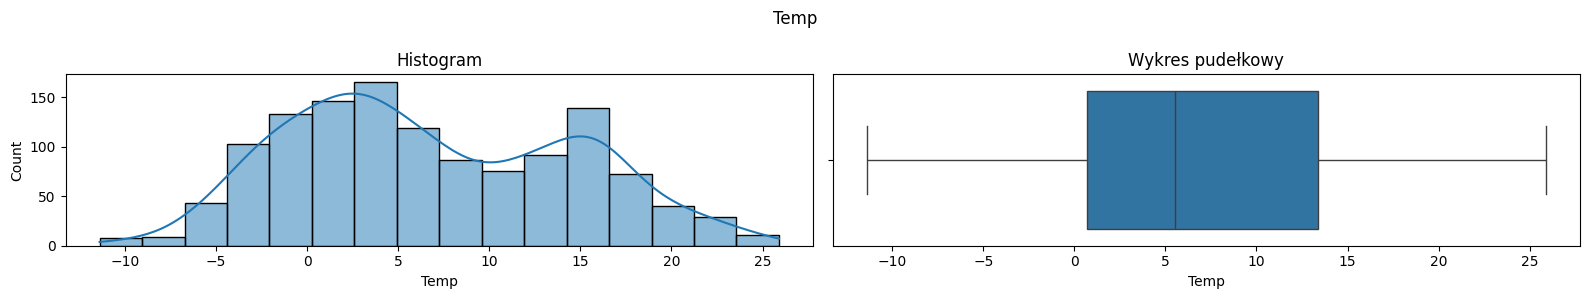

In [12]:
for variable in dataframe.select_dtypes(include=np.number).columns:  # Iteracja po kolumnach numerycznych
    fig, axes = plt.subplots(1, 2, figsize=(16, 3))                   # Utworzenie dwóch wykresów obok siebie
    fig.suptitle(variable, fontsize=12)                              # Ustawienie nazwy analizowanej kolumny

    sns.histplot(                                                     # Utworzenie histogramu
        data=dataframe,
        x=variable,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title('Histogram')                                   # Nadanie tytułu histogramowi

    sns.boxplot(                                                      # Utworzenie wykresu pudełkowego
        data=dataframe,
        x=variable,
        ax=axes[1]
    )
    axes[1].set_title('Wykres pudełkowy')                            # Nadanie tytułu wykresowi pudełkowemu

    plt.tight_layout()                                               # Dopasowanie odstępów między elementami
    plt.show()                                                       # Wyświetlenie wykresów

Nasza zmienna objaśniana y nie ma rozkładu normalnego.

To znaczy, że wartości zmiennej y — liczby dziennych wypożyczeń rowerów — nie układają się zgodnie z rozkładem normalnym, czyli symetryczną krzywą w kształcie dzwonu.
W rozkładzie normalnym:
- większość obserwacji znajduje się w pobliżu średniej,
- małe i duże wartości występują coraz rzadziej,
- rozkład jest symetryczny,
- średnia i mediana są do siebie zbliżone.
- 
W Twoich danych rozkład może być na przykład skośny, mieć kilka szczytów albo zawierać dużo wartości skrajnych. Jest to całkiem logiczne dla wypożyczeń rowerów, ponieważ ich liczba zależy m.in. od sezonu, pogody, weekendów i trendu w czasie.
Nie oznacza to automatycznie problemu. W regresji liniowej zmienna y sama w sobie nie musi mieć rozkładu normalnego. Założenie normalności, jeśli jest potrzebne do wnioskowania statystycznego, dotyczy przede wszystkim reszt modelu, czyli różnic:

Zmienna objaśniana nie ma rozkładu normalnego, co może wynikać z sezonowości, trendu oraz wpływu warunków pogodowych i kalendarzowych. Nie jest to samo w sobie przeszkodą w modelowaniu regresyjnym, ponieważ normalność zmiennej objaśnianej nie jest ogólnym wymaganiem modeli regresji. W przypadku regresji liniowej należy przeanalizować przede wszystkim rozkład reszt modelu.



14:46

Wracając do naszej zmiennej liczby wypożyczonych rowerów, czy jest to problem? Jeśli stosujemy modele parametryczne (czyli regresja liniowa, SVM, sieć neuronowa), to lubią one zmienne z rozkładu normalnego. Aby doprowadzić taką zmienną do rozkładu gaussowskiego, warto na przykład zlogarytmować tę zmienną, możesz zastosować PoweTransformer z biblioteki skcikit-learn.

Dla deszczu widzimy, że jest sporo wartości odstających, a to dlatego, że zazwyczaj nie ma opadów.

Co do temperatury to widać, że jest ona najczęściej w okolicach 7°C lub 15°C.

Teraz czas sprawdzić jak liczba wypożyczonych rowerów jest wyjaśniona przez samą siebie w czasie (sezonowość, trend) oraz jak zależy od zewnętrznych zmiennych, takich jak opady deszczu czy temperatura.

# Jak wygląda liczba wypożyczonych rowerów w czasie?

Zróbmy wizualizację liczby wypożyczonych rowerów względem poszczególnych dni. Spodziewać się możemy pewnej sezonowości tygodniowej (w jeden dzień tygodnia jest średnio więcej wypożyczeń niż w inny), zatem dodajmy średnią kroczącą siedmiodniową

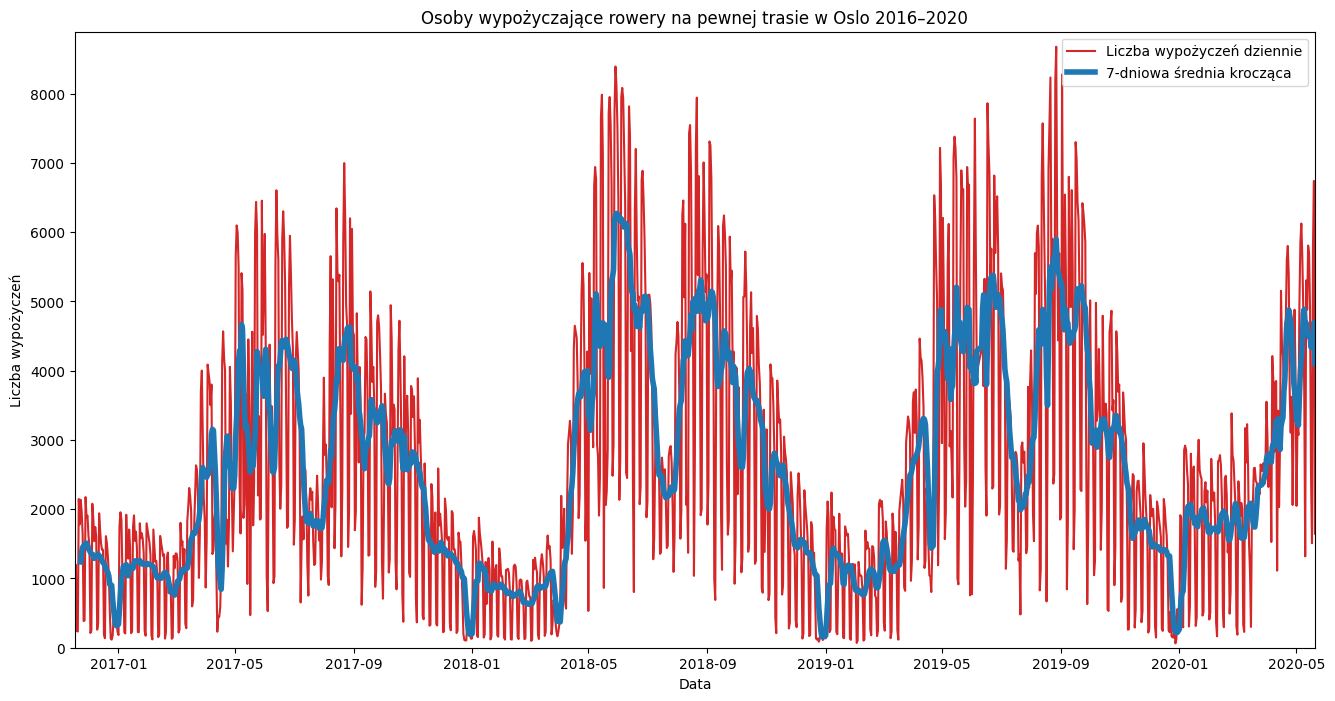

In [14]:
plt.figure(figsize=(16, 8), dpi=100)                              # Utworzenie wykresu o wymiarach 16 × 8 cali i rozdzielczości 100 DPI
plt.plot(dataframe['Date'], dataframe['Volume'],                  # Narysowanie dziennej liczby wypożyczeń w czasie
         color='tab:red', label='Liczba wypożyczeń dziennie')     # Ustawienie koloru linii oraz opisu w legendzie
plt.plot(dataframe['Date'], dataframe['Volume'].rolling(7).mean(), # Narysowanie 7-dniowej średniej kroczącej
         color='tab:blue', linewidth=4,                            # Ustawienie koloru i grubości linii
         label='7-dniowa średnia krocząca')                        # Ustawienie opisu linii w legendzie
plt.title('Osoby wypożyczające rowery na pewnej trasie w Oslo 2016–2020')  # Nadanie tytułu wykresowi
plt.xlabel('Data')                                                 # Nadanie etykiety osi poziomej
plt.ylabel('Liczba wypożyczeń')                                    # Nadanie etykiety osi pionowej
plt.xlim([dataframe['Date'].min(), dataframe['Date'].max()])       # Ustawienie zakresu osi X na cały okres danych
plt.ylim([0, dataframe['Volume'].max() * 1.025])                   # Ustawienie zakresu osi Y z niewielkim zapasem nad maksimum
plt.legend(loc='upper right')                                      # Wyświetlenie legendy w prawym górnym rogu
plt.show()                                                         # Wyświetlenie gotowego wykresu

Widać sporą wariancję liczby wypożyczonych rowerów, co zapewne jest powodem sezonowości tygodniowej. Gdybyśmy policzyli wszystkie ‘górki’ w danym roku, to otrzymalibyśmy liczbę tygodni w roku. Ponadto widać też pewną sezonowość roczną (warto tutaj patrzeć na średnią kroczącą), wartość wypożyczonych rowerów wzrasta do wakacji, aby potem spaść i ponownie wzrosnąć. Nie musimy patrzeć na temperaturę, aby domyślać się, że zimą będzie mniej wypożyczonych rowerów, niż w miesiące ciepłe.

Aby zweryfikować domysły co do sezonowości, sprawdzić trend, stwórzmy kopię ramki danych dla pełnych lat. Nie bierzemy zatem roku 2016 oraz 2020, ponieważ tutaj nie mamy danych dla całego roku. Dodajemy do obserwacji informację, jaki to rok, miesiąc i dzień tygodnia.

In [15]:
full_years = dataframe.loc[                                      # Wybranie danych z pełnych lat 2017–2019
    (dataframe['Date'] >= '2017-01-01') &                        # Ustawienie początku analizowanego okresu
    (dataframe['Date'] < '2020-01-01')                           # Ustawienie końca okresu bez uwzględnienia 2020 roku
].copy()                                                         # Utworzenie niezależnej kopii wybranych danych

full_years['year'] = full_years['Date'].dt.year                  # Utworzenie kolumny zawierającej rok
full_years['month'] = full_years['Date'].dt.strftime('%b')       # Utworzenie kolumny z krótką nazwą miesiąca
full_years['weekday'] = full_years['Date'].dt.strftime('%A')     # Utworzenie kolumny z nazwą dnia tygodnia

full_years                                                        # Wyświetlenie przygotowanego DataFrame'u

,Date,Volume,Rain,Temp,year,month,weekday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday
...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday


Następnie zagregujmy zbiór danych do poziomu rok/miesiąc i jako funkcję agregującą wykorzystajmy średnią.

In [16]:
full_years_monthly = full_years.groupby(                         # Grupowanie danych według roku i miesiąca
    ['year', 'month']
)[['Volume']].mean()                                             # Obliczenie średniej dziennej liczby wypożyczeń w każdej grupie

full_years_monthly.reset_index(inplace=True)                     # Przeniesienie roku i miesiąca z indeksu do zwykłych kolumn

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",              # Zdefiniowanie miesięcy w kolejności kalendarzowej
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

full_years_monthly['month'] = pd.Categorical(                    # Zamiana kolumny month na uporządkowaną kategorię
    full_years_monthly['month'],
    categories=months,                                           # Określenie poprawnej kolejności miesięcy
    ordered=True
)

full_years_monthly.sort_values(                                  # Posortowanie danych chronologicznie
    by=['year', 'month'],
    inplace=True
)

display(full_years_monthly.head(3))                              # Wyświetlenie pierwszych trzech wierszy
display(full_years_monthly.tail(3))                              # Wyświetlenie ostatnich trzech wierszy

,year,month,Volume
4,2017,Jan,1202.225806
3,2017,Feb,980.250000
7,2017,Mar,1703.419355


,year,month,Volume
34,2019,Oct,3204.967742
33,2019,Nov,1852.500000
26,2019,Dec,1035.580645


Stworzyliśmy nowe zbiory danych, które pomogą nam w analizie danych pod względem sezonowości czy trendu. Najpierw skorzystajmy z drugiej ramki danych i zróbmy wykres liniowy średniej liczby wypożyczeń rowerów w zależności od miesiąca dla lat 2017, 2018 oraz 2019.

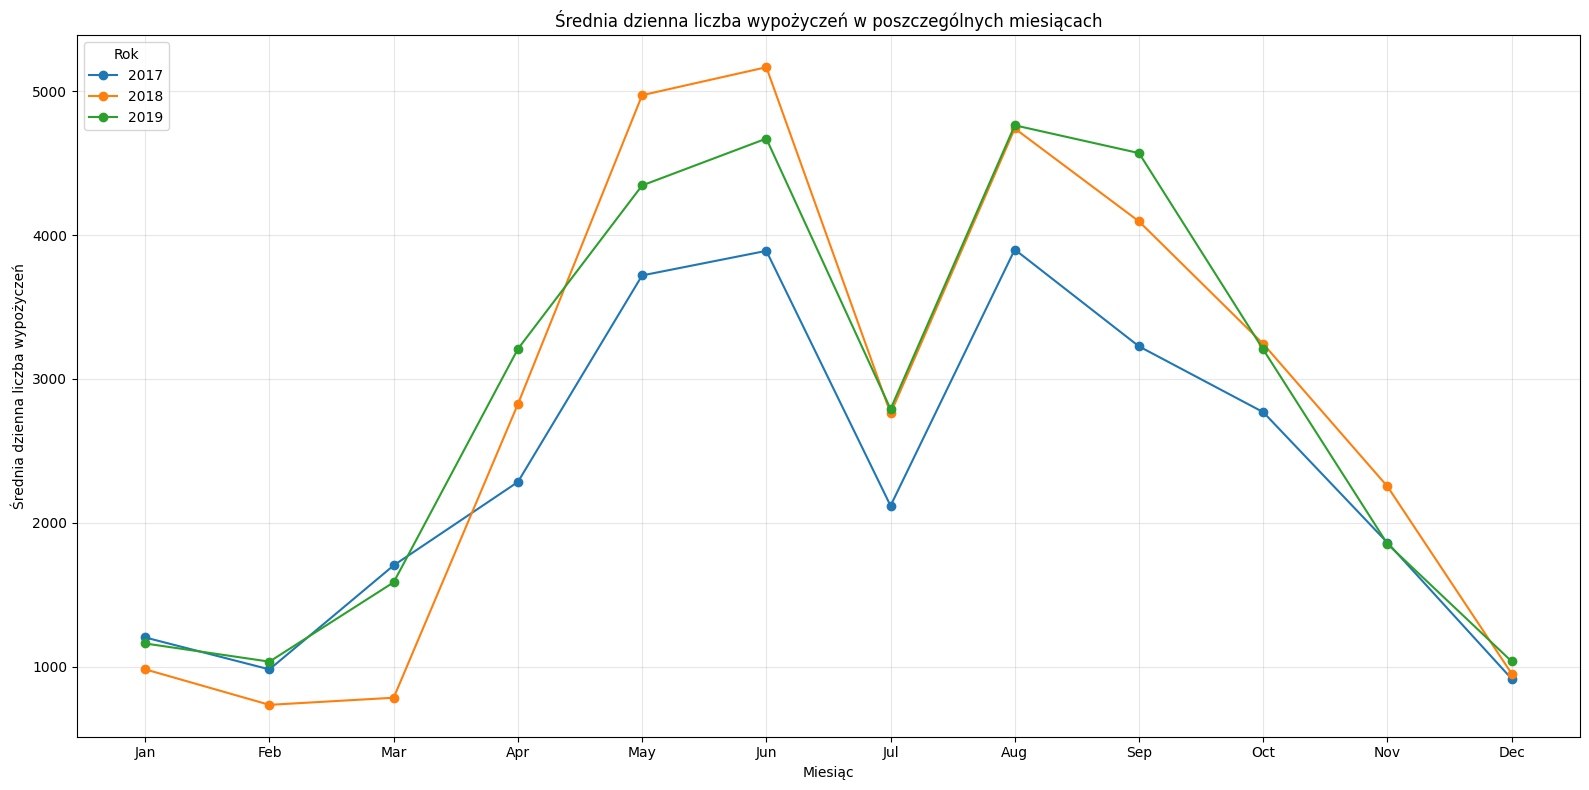

In [17]:
plt.figure(figsize=(16, 8), dpi=100)                                  # Utworzenie wykresu o wymiarach 16 × 8 cali

for year in full_years['year'].unique():                              # Iteracja po wszystkich analizowanych latach
    yearly_data = full_years_monthly.loc[                              # Wybranie danych miesięcznych dla danego roku
        full_years_monthly['year'] == year
    ]

    plt.plot(                                                          # Narysowanie średniej liczby wypożyczeń w kolejnych miesiącach
        yearly_data['month'],
        yearly_data['Volume'],
        marker='o',                                                    # Dodanie punktów odpowiadających poszczególnym miesiącom
        label=str(year)
    )

plt.title('Średnia dzienna liczba wypożyczeń w poszczególnych miesiącach')  # Nadanie tytułu wykresowi
plt.xlabel('Miesiąc')                                                  # Nadanie etykiety osi poziomej
plt.ylabel('Średnia dzienna liczba wypożyczeń')                        # Nadanie etykiety osi pionowej
plt.legend(title='Rok', loc='upper left')                              # Wyświetlenie legendy z oznaczeniami lat
plt.xticks(months)                                                     # Wyświetlenie wszystkich miesięcy w kolejności kalendarzowej
plt.grid(alpha=0.3)                                                    # Dodanie delikatnej siatki ułatwiającej odczyt wartości
plt.tight_layout()                                                     # Automatyczne dopasowanie elementów wykresu
plt.show()                                                             # Wyświetlenie gotowego wykresu

To, co najciekawsze, zależności są stałe dla lat. W miesiące zimne, takie jak grudzień, styczeń czy luty, widzimy najmniejszą średnią liczbę wypożyczonych rowerów. Inną ciekawą zależnością jest to, co widzieliśmy już wcześniej, dla lipca mamy znaczący spadek, być może ma to związek z tym, że mieszkańcy Oslo w tym czasie wyjeżdżają z miasta na upragnione wakacje. To co możesz też zauważyć dla 2017 roku – wartości są zazwyczaj niewiele niższe, co jest zauważalne.

Te zależności w inżynierii cech będziemy musieli przekazać modelowi, aby dane surowe zamienić w informacje, które model przekształci w mądrość.

To oczywiście nie koniec. Dokończmy proces sprawdzania sezonowości, do tego wykorzystamy wykresy pudełkowe:

- Rok (trend)
- Miesiąc (sezonowość)- 
- Dzień tygodnia (sezonowość)

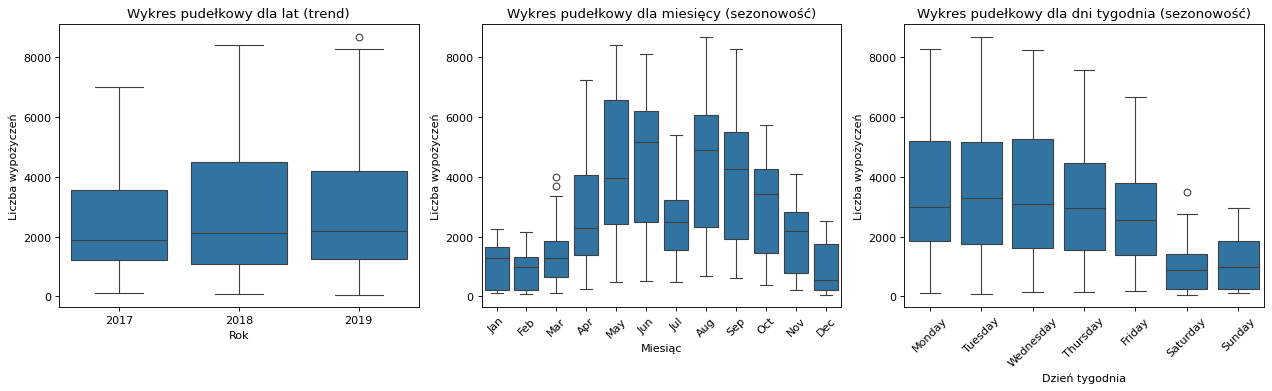

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=80)               # Utworzenie figury składającej się z trzech wykresów

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla poszczególnych lat
    x='year',
    y='Volume',
    data=full_years,
    ax=axes[0]
)
axes[0].set(                                                           # Ustawienie opisów osi pierwszego wykresu
    xlabel='Rok',
    ylabel='Liczba wypożyczeń'
)
axes[0].set_title('Wykres pudełkowy dla lat (trend)')                  # Nadanie tytułu pierwszemu wykresowi

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla poszczególnych miesięcy
    x='month',
    y='Volume',
    data=full_years,
    order=months,                                                      # Ustawienie miesięcy w kolejności kalendarzowej
    ax=axes[1]
)
axes[1].set(                                                           # Ustawienie opisów osi drugiego wykresu
    xlabel='Miesiąc',
    ylabel='Liczba wypożyczeń'
)
axes[1].set_title('Wykres pudełkowy dla miesięcy (sezonowość)')        # Nadanie tytułu drugiemu wykresowi
axes[1].tick_params(axis='x', rotation=45)                             # Obrócenie nazw miesięcy dla lepszej czytelności

weekdays = [                                                           # Zdefiniowanie dni tygodnia w odpowiedniej kolejności
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla dni tygodnia
    x='weekday',
    y='Volume',
    data=full_years,
    order=weekdays,                                                    # Ustawienie dni od poniedziałku do niedzieli
    ax=axes[2]
)
axes[2].set(                                                           # Ustawienie opisów osi trzeciego wykresu
    xlabel='Dzień tygodnia',
    ylabel='Liczba wypożyczeń'
)
axes[2].set_title('Wykres pudełkowy dla dni tygodnia (sezonowość)')    # Nadanie tytułu trzeciemu wykresowi
axes[2].tick_params(axis='x', rotation=45)                             # Obrócenie nazw dni tygodnia

plt.tight_layout()                                                     # Dopasowanie odstępów pomiędzy wykresami
plt.show()                                                             # Wyświetlenie gotowych wykresów

- Trend – nie widać, aby trend nadal obowiązywał, jednak liczba wypożyczonych rowerów dla 2017 roku była niższa. Może na przełomie 2017 i 2018 roku była akcja promocyjna, aby przestać korzystać z samochodu?
- Sezonowość roczna – ten temat już dobrze zbadaliśmy.
- Sezonowość tygodniowa – stąd wariancja. W dni robocze jest większa liczba wypożyczonych rowerów niż w weekend. Idąc dalej, widać różnice pomiędzy początkiem tygodnia (poniedziałek), a końcem tygodnia roboczego (piątek). Być może z powodu lenistwa część osób odpuszcza jazdę rowerem, a może wtedy pracownicy IT pracują zdalnie, a może jadą samochodem w piątek do pracy, aby po niej jak najszybciej wyjechać na weekend poza miasto, a może powód jest jeszcze inny. W tym przypadku powód nie jest najważniejszy, najważniejsza jest zależność, która jest znacząca i również warto to też zastosować podczas inżynierii cech.

Uff… Już rozumiemy, jak ma się liczba wypożyczonych rowerów w zależności od daty. Ale czy na pewno?

NIE! Poza typowymi dniami tygodnia może wystąpić święto i czasem co roku występuje w ten sam dzień tygodnia (np. Wielkanoc), jak i może wystąpić w różne dni (Święto Niepodległości, Boże Narodzenie).

Skorzystajmy z biblioteki holidays i dodajmy święta dla Norwegii. Ważne aby zauważyć, że niedziela („Søndag”) traktowana jest jako święto, nie bierzemy pod uwagę tego święta. Tworzymy funkcję get_holiday, którą aplikujemy do wcześniej stworzonej ramki danych full_years i dzięki niej otrzymujemy nową zmienną Holiday z wskazanym świętem (lub nie, jeśli nie było – większość okresu) dla konkretnej daty.

In [22]:
import holidays

In [23]:
holidays_Norway = holidays.NO()                                      # Utworzenie kalendarza norweskich świąt

def get_holiday(row):                                                # Zdefiniowanie funkcji przypisującej nazwę święta do daty
    holiday_name = holidays_Norway.get(row['Date'])                  # Pobranie nazwy święta przypadającego na daną datę

    if holiday_name is None:                                         # Sprawdzenie, czy dany dzień nie jest świętem
        return np.nan                                                 # Zwrócenie brakującej wartości dla zwykłego dnia

    if holiday_name == 'Søndag':                                     # Sprawdzenie, czy jedynym świętem jest niedziela
        return np.nan                                                 # Pominięcie niedzieli jako osobnego święta

    if 'Søndag' in holiday_name:                                     # Sprawdzenie, czy niedziela pokrywa się z innym świętem
        holiday_name = holiday_name.replace('Søndag', '')            # Usunięcie określenia „Søndag” z nazwy święta
        holiday_name = holiday_name.replace(',', '')                 # Usunięcie zbędnego przecinka
        holiday_name = holiday_name.strip()                           # Usunięcie zbędnych spacji

    return holiday_name                                               # Zwrócenie nazwy właściwego święta


full_years['Holiday'] = full_years.apply(                             # Utworzenie kolumny zawierającej nazwy świąt
    get_holiday,
    axis=1                                                            # Zastosowanie funkcji osobno do każdego wiersza
)

print('Unikalne święta:')                                            # Wyświetlenie nagłówka wyników
print(full_years['Holiday'].value_counts())                           # Wyświetlenie liczby wystąpień poszczególnych świąt

full_years                                                            # Wyświetlenie DataFrame’u z nową kolumną

Unikalne święta:
Holiday
Første nyttårsdag        3
Skjærtorsdag             3
Langfredag               3
Første påskedag          3
Andre påskedag           3
Arbeidernes dag          3
Grunnlovsdag             3
Kristi himmelfartsdag    3
Første juledag           3
Andre juledag            3
Første pinsedag          2
Andre pinsedag           2
Name: count, dtype: int64


,Date,Volume,Rain,Temp,year,month,weekday,Holiday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday,Første nyttårsdag
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday,NaN
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday,NaN
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday,NaN
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday,NaN
...,...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday,NaN
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday,NaN
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday,NaN
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday,NaN


Być może nie znasz języka norweskiego, dlatego poniżej przygotowaliśmy dla Ciebie słownik świąt:

Første juledag - Pierwszy dzień Świąt Bożego Narodzenia
Andre juledag - Drugi dzień Świąt Bożego Narodzenia
Første nyttårsdag - Nowy Rok
Skjærtorsdag - Wielki Czwartek
Langfredag - Wielki Piątek
Første påskedag - Pierwszy dzień Wielkanocy
Andre påskedag - Drugi dzień Wielkanocy
Arbeidernes dag - Dzień Pracy
Grunnlovsdag - Dzień Konstytucji
Kristi himmelfartsdag - Dzień Wniebowstąpienia
Første pinsedag - Pierwszy dzień Zielonych Świąt
Andre pinsedag - Drugi dzień Zielonych Świąt

Mamy już święta, zatem chcielibyśmy sprawdzić ich wpływ na liczbę wypożyczonych rowerów. Jak to w analizie danych, jedną rzecz można sprawdzić na wiele sposobów. Wykorzystamy wykres pudełkowy dla zakresu miesiąca, w których święto wystąpiło z rozróżnieniem czy było to święto czy nie w danych miesiącach.

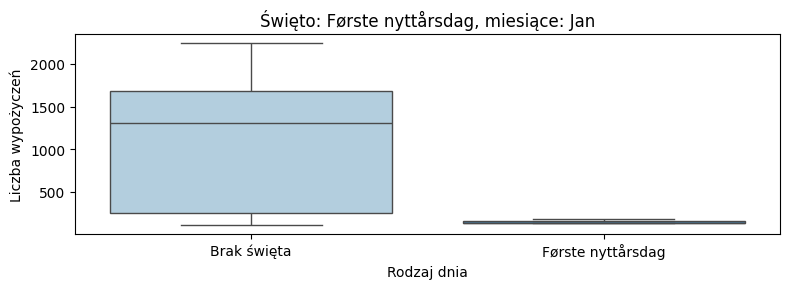

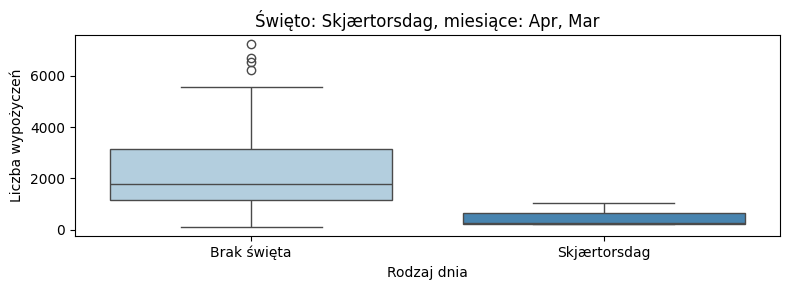

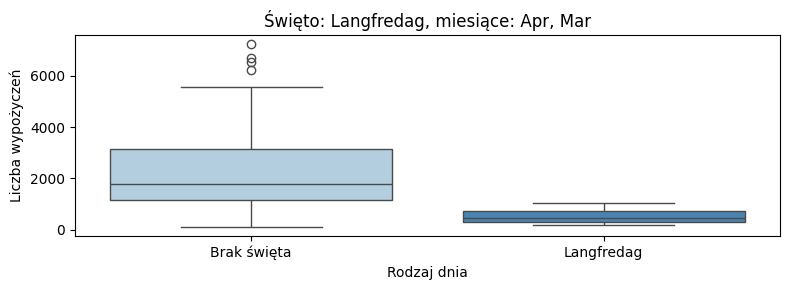

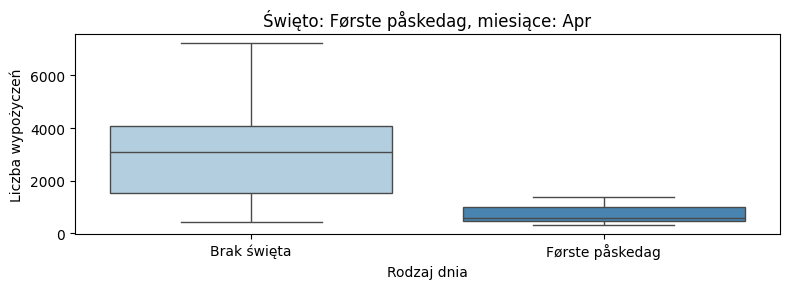

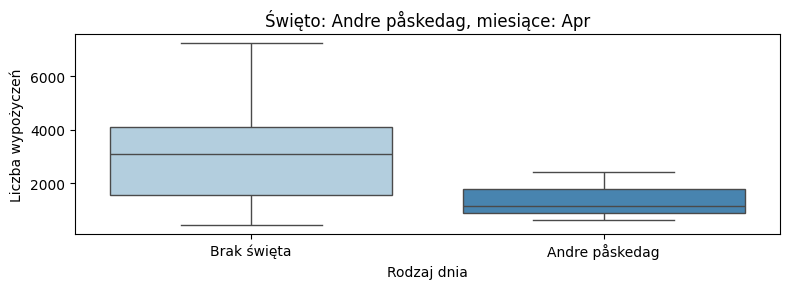

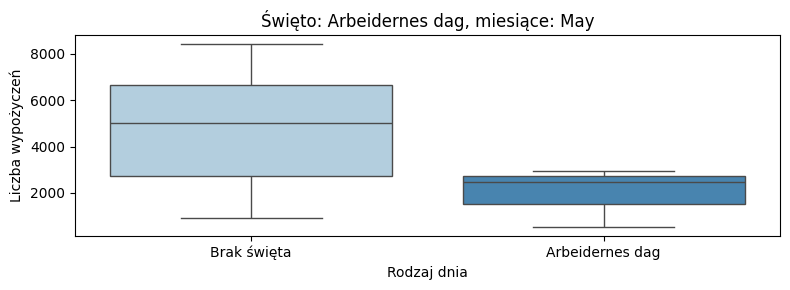

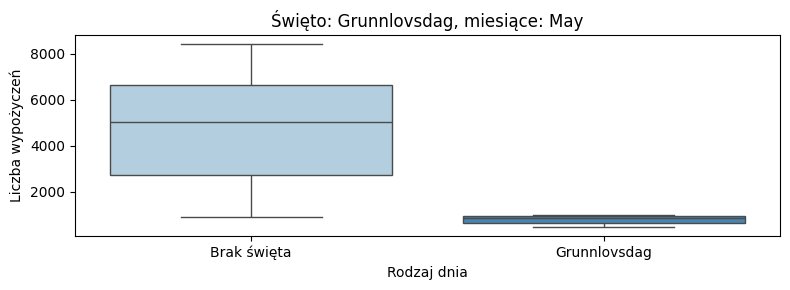

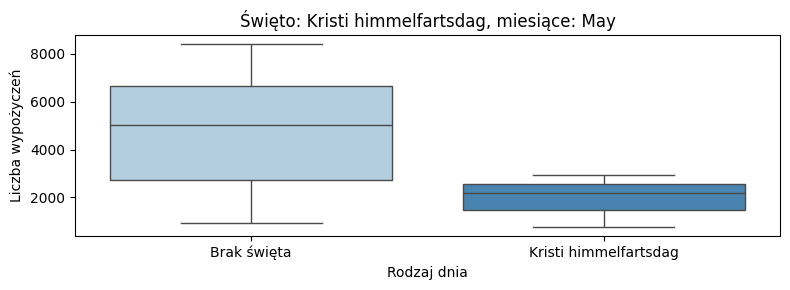

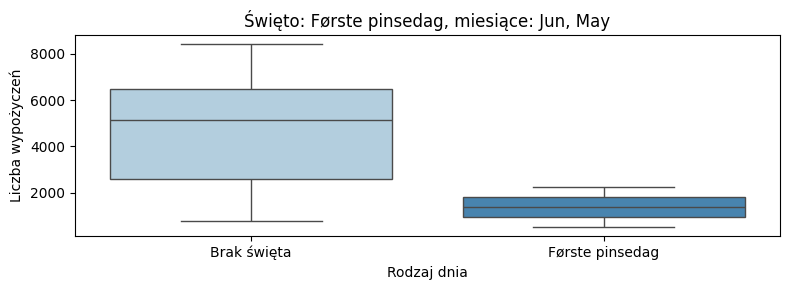

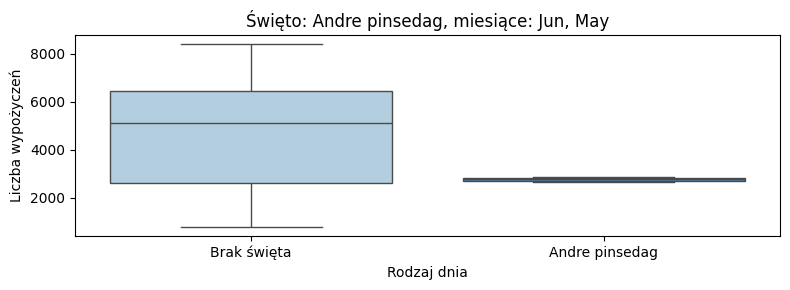

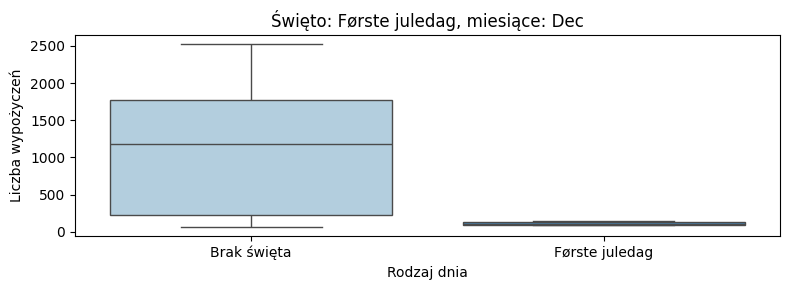

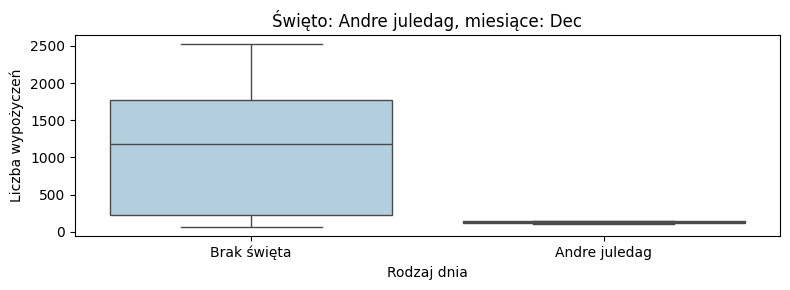

In [24]:
for unique_holiday in full_years['Holiday'].dropna().unique():             # Iteracja po wszystkich unikalnych świętach

    month_holiday = full_years.loc[                                         # Wybranie miesięcy, w których występuje dane święto
        full_years['Holiday'] == unique_holiday,
        'month'
    ].unique()

    selected_holiday = full_years.loc[                                     # Wybranie obserwacji z odpowiednich miesięcy
        full_years['month'].isin(month_holiday) &                           # Ograniczenie danych do miesięcy występowania święta
        (
            full_years['Holiday'].isna() |                                 # Uwzględnienie dni bez święta
            (full_years['Holiday'] == unique_holiday)                       # Uwzględnienie analizowanego święta
        )
    ].copy()

    selected_holiday['Holiday'] = selected_holiday['Holiday'].fillna(       # Zastąpienie brakujących wartości opisem
        'Brak święta'
    )

    holiday_order = ['Brak święta', unique_holiday]                         # Ustalenie kolejności kategorii na wykresie

    plt.figure(figsize=(8, 3))                                              # Utworzenie obszaru wykresu

    sns.boxplot(                                                             # Utworzenie wykresu pudełkowego
        data=selected_holiday,
        x='Holiday',
        y='Volume',
        hue='Holiday',                                                       # Ustawienie kategorii odpowiadającej kolorom
        order=holiday_order,
        hue_order=holiday_order,
        palette='Blues',
        legend=False                                                         # Ukrycie zbędnej legendy
    )

    months_text = ', '.join(map(str, month_holiday))                        # Połączenie nazw miesięcy w jeden napis
    plt.title(f'Święto: {unique_holiday}, miesiące: {months_text}')          # Nadanie tytułu wykresowi
    plt.xlabel('Rodzaj dnia')                                                # Nadanie etykiety osi poziomej
    plt.ylabel('Liczba wypożyczeń')                                          # Nadanie etykiety osi pionowej
    plt.tight_layout()                                                       # Dopasowanie elementów wykresu
    plt.show()                                                               # Wyświetlenie wykresu

Wszystkie święta są niczym weekendy, zauważalna jest zdecydowana mniejsza liczba wypożyczeń. Czy możemy stworzyć dla każdego święta One Hot Encoder? Niekoniecznie, święta są bardzo rzadkimi wydarzeniami, weźmy na przykład Wielkanoc – występuje jedynie raz w roku. Taka zmienna byłaby bardzo rzadka. Sprawdźmy wykres pudełkowy, gdybyśmy wszystkie święta połączyli w jedną wartość, czyli rozdzielili sytuacje – jest święto bądź go nie ma, nieważne jakie święto.

In [25]:
full_years['Holiday'] = (                                              # Przekształcenie nazw świąt na zmienną binarną
    full_years['Holiday']
    .notna()                                                           # Zwrócenie True dla święta i False dla zwykłego dnia
    .astype(int)                                                       # Zamiana True na 1, a False na 0
)

full_years                                                             # Wyświetlenie zmodyfikowanego DataFrame’u

,Date,Volume,Rain,Temp,year,month,weekday,Holiday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday,1
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday,0
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday,0
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday,0
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday,0
...,...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday,0
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday,0
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday,0
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday,0


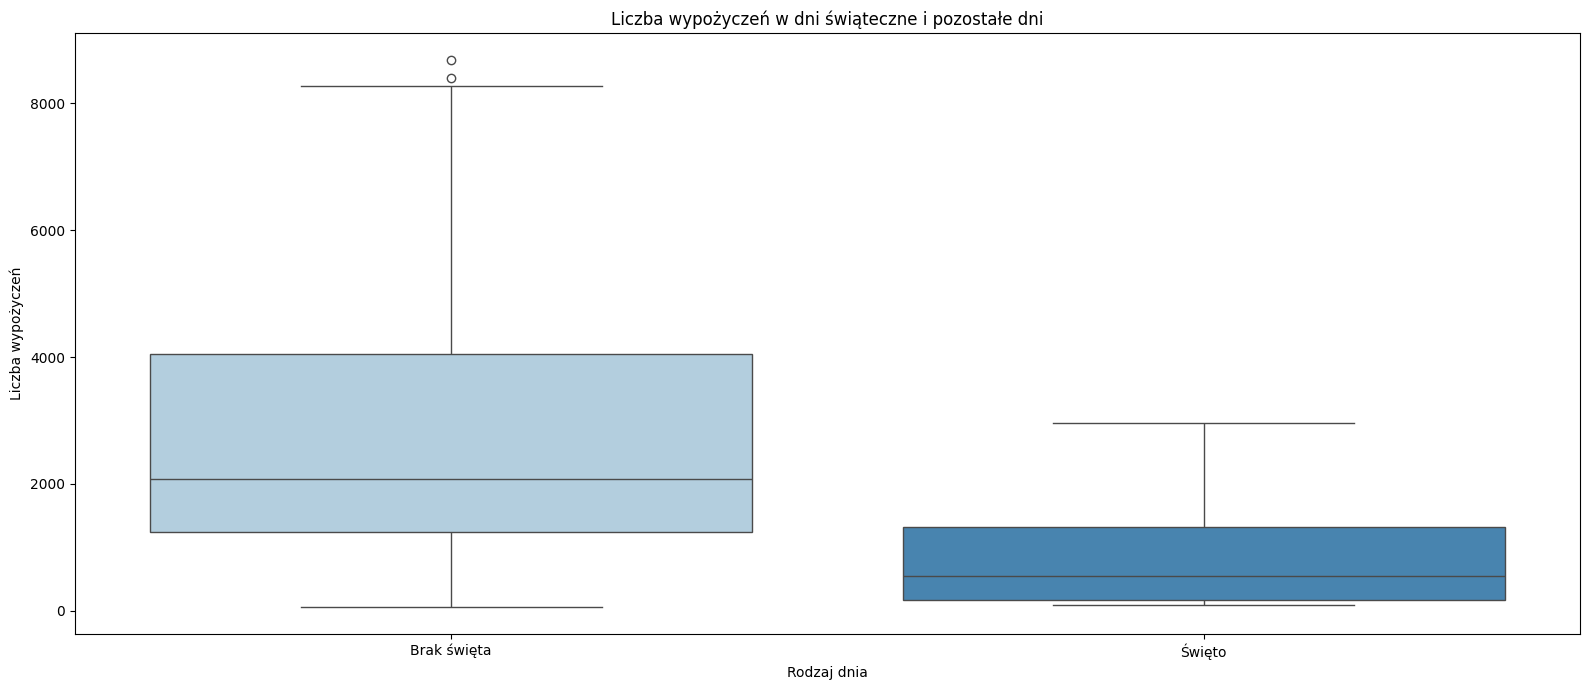

In [26]:
plt.figure(figsize=(16, 7))                                           # Utworzenie obszaru wykresu o wymiarach 16 × 7 cali

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego porównującego rodzaje dni
    data=full_years,
    x='Holiday',
    y='Volume',
    hue='Holiday',                                                     # Przypisanie kolorów według wartości kolumny Holiday
    palette='Blues',
    legend=False                                                       # Ukrycie zbędnej legendy
)

plt.title('Liczba wypożyczeń w dni świąteczne i pozostałe dni')       # Nadanie tytułu wykresowi
plt.xlabel('Rodzaj dnia')                                              # Nadanie etykiety osi poziomej
plt.ylabel('Liczba wypożyczeń')                                        # Nadanie etykiety osi pionowej
plt.xticks([0, 1], ['Brak święta', 'Święto'])                         # Zamiana wartości 0 i 1 na czytelne opisy
plt.tight_layout()                                                     # Dopasowanie elementów wykresu
plt.show()                                                             # Wyświetlenie gotowego wykresu

Święto ma zdecydowany wpływ na liczbę wypożyczonych rowerów.

Sprawdźmy jeszcze zależność obserwacji od szeregu opóźnień. Wykres zależności obserwacji szeregu od opóźnień zwykle służy do sprawdzania autokorelacji. Jeśli na wykresie rozproszenia zauważalny jest jakikolwiek wzorzec, wówczas możemy sądzić, że szereg jest autoskorelowany. Jeśli punkty układają się w sposób losowy, wówczas będzie przypadkowym białym szumem.

In [27]:
# TLUMACZNIE

Drugi fragment dotyczy autokorelacji, czyli zależności bieżącej liczby wypożyczeń od wcześniejszych wartości tego samego szeregu.
Przykładowo:

-opóźnienie 1 porównuje dzisiejszą liczbę wypożyczeń z liczbą z poprzedniego dnia,
-opóźnienie 7 porównuje ją z tym samym dniem poprzedniego tygodnia,
-opóźnienie 14 — z wartością sprzed dwóch tygodni,
-opóźnienie 365 — z podobnym dniem poprzedniego roku.

Jeśli na wykresie punktowym wartości układają się mniej więcej wzdłuż rosnącej linii, oznacza to dodatnią autokorelację: po dniach z dużą liczbą wypożyczeń często występują podobnie wysokie wartości.

Jeżeli punkty układają się wzdłuż linii malejącej, występuje autokorelacja ujemna: po wysokich wartościach częściej pojawiają się niskie.
Jeśli punkty tworzą bezkształtną, losową chmurę, dla danego opóźnienia nie widać wyraźnej zależności.
W przypadku wypożyczeń rowerów można spodziewać się autokorelacji, ponieważ:
pogoda często utrzymuje się przez kilka kolejnych dni,
występuje tygodniowy cykl aktywności,
liczba wypożyczeń zależy od sezonu,
popularność wypożyczeń może zmieniać się długoterminowo.

„Biały szum” oznacza natomiast szereg losowych, wzajemnie niezależnych wartości, bez trendu, sezonowości i autokorelacji. Surowe dane o wypożyczeniach raczej nie będą białym szumem.
Ważna korekta językowa: powinno być „szereg jest autokorelowany”, a nie „autoskorelowany”. Ponadto brak wzorca na jednym wykresie opóźnienia nie wystarcza, aby uznać cały szereg za biały szum — należy sprawdzić wiele opóźnień, np. za pomocą wykresów ACF i testu Ljunga–Boxa.

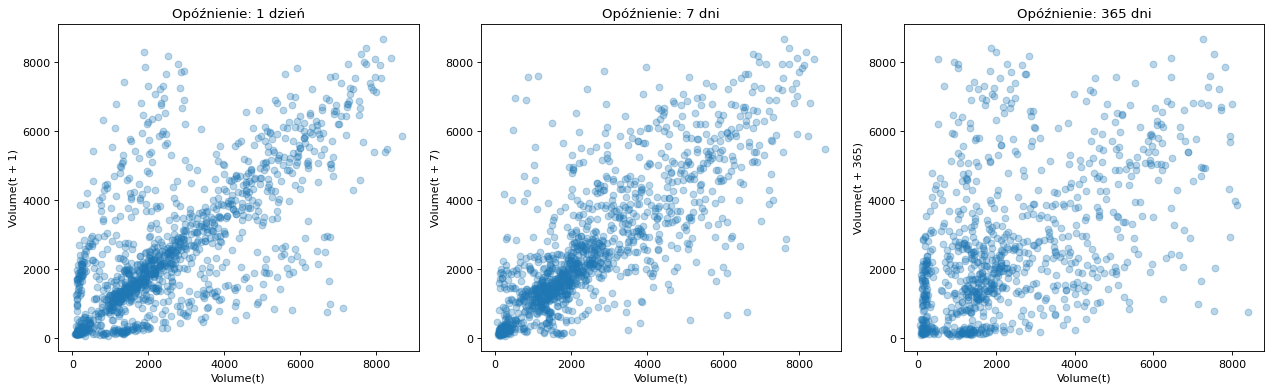

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=80)                  # Utworzenie figury z trzema wykresami opóźnień

pd.plotting.lag_plot(                                                    # Porównanie bieżących wartości z poprzednim dniem
    dataframe['Volume'],
    lag=1,                                                               # Ustawienie opóźnienia wynoszącego jeden dzień
    ax=axes[0],
    alpha=0.3                                                            # Ustawienie przezroczystości punktów
)
axes[0].set_title('Opóźnienie: 1 dzień')                                # Nadanie tytułu pierwszemu wykresowi
axes[0].set_xlabel('Volume(t)')                                         # Oznaczenie wartości bieżącej na osi X
axes[0].set_ylabel('Volume(t + 1)')                                     # Oznaczenie wartości przesuniętej na osi Y

pd.plotting.lag_plot(                                                    # Porównanie wartości oddalonych o jeden tydzień
    dataframe['Volume'],
    lag=7,                                                               # Ustawienie opóźnienia wynoszącego siedem dni
    ax=axes[1],
    alpha=0.3
)
axes[1].set_title('Opóźnienie: 7 dni')                                  # Nadanie tytułu drugiemu wykresowi
axes[1].set_xlabel('Volume(t)')
axes[1].set_ylabel('Volume(t + 7)')

pd.plotting.lag_plot(                                                    # Porównanie wartości oddalonych o około jeden rok
    dataframe['Volume'],
    lag=365,                                                             # Ustawienie opóźnienia wynoszącego 365 dni
    ax=axes[2],
    alpha=0.3
)
axes[2].set_title('Opóźnienie: 365 dni')                                # Nadanie tytułu trzeciemu wykresowi
axes[2].set_xlabel('Volume(t)')
axes[2].set_ylabel('Volume(t + 365)')

plt.tight_layout()                                                       # Dopasowanie odstępów między wykresami
plt.show()                                                               # Wyświetlenie gotowych wykresów

Uwaga: lag=365 oznacza 365 wierszy, a niekoniecznie 365 dni. Ponieważ w danych brakuje kilku dat, przed analizą należy uporządkować dane i utworzyć pełny dzienny indeks. W przeciwnym razie opóźnienia mogą nie odpowiadać rzeczywistym odstępom kalendarzowym

Przez to, że mamy sezonowość tygodniową, to wartość dzisiejsza jest bardziej podobna do wartości z poprzedniego tygodnia niż do wartości z wczoraj. Tutaj powinna zapalić Ci się lampka i podpowiedź, jak to wykorzystać, ale spokojnie – wrócimy jeszcze do tego.

Na tę część poświęciliśmy trochę czasu, ale uwierz nam – pomoże to przy przetworzeniu danych, a następnie przy modelowaniu.

In [29]:
# TLUMACZENIE

Oznacza to, że liczba wypożyczeń dzisiaj może być bardziej zbliżona do liczby wypożyczeń w tym samym dniu poprzedniego tygodnia niż wczoraj.
Przykładowo:
dzisiejszy poniedziałek porównujemy z poprzednim poniedziałkiem (lag=7),
porównanie dzisiejszego poniedziałku z niedzielą (lag=1) może wykazać słabsze podobieństwo.
Wynika to z tygodniowego rytmu wypożyczeń. Dni robocze mogą zachowywać się inaczej niż weekendy, dlatego obserwacje oddalone o 7 dni często są do siebie podobne.
„Lampka” oznacza sugestię, żeby wykorzystać tę zależność podczas budowania modelu. Można utworzyć cechy opóźnione:
dataframe['Volume_lag_1'] = dataframe['Volume'].shift(1)     # Liczba wypożyczeń wczoraj
dataframe['Volume_lag_7'] = dataframe['Volume'].shift(7)     # Liczba wypożyczeń tydzień wcześniej
dataframe['Volume_lag_14'] = dataframe['Volume'].shift(14)   # Liczba wypożyczeń dwa tygodnie wcześniej
Model otrzyma wtedy informację o wcześniejszych wartościach i może nauczyć się zależności:
Jeżeli w poprzedni poniedziałek wypożyczeń było dużo, w bieżący poniedziałek również prawdopodobnie będzie ich dużo.

Możesz także zastosować średnią kroczącą:
dataframe['Volume_rolling_7'] = (
    dataframe['Volume']
    .shift(1)                    # Wykluczenie wartości z bieżącego dnia
    .rolling(7)
    .mean()
)
shift(1) jest tutaj bardzo ważne — bez niego średnia zawierałaby dzisiejszą wartość Volume, czyli zmienną, którą model ma przewidzieć. Byłby to wyciek danych.
Ważne zastrzeżenie: cechę Volume_lag_7 można wykorzystać tylko wtedy, gdy podczas wykonywania prognozy wartość sprzed siedmiu dni jest już znana. Podział danych na treningowe i testowe powinien być chronologiczny, a nie losowy.

# Wpływ pogody na liczbę rowerzystów

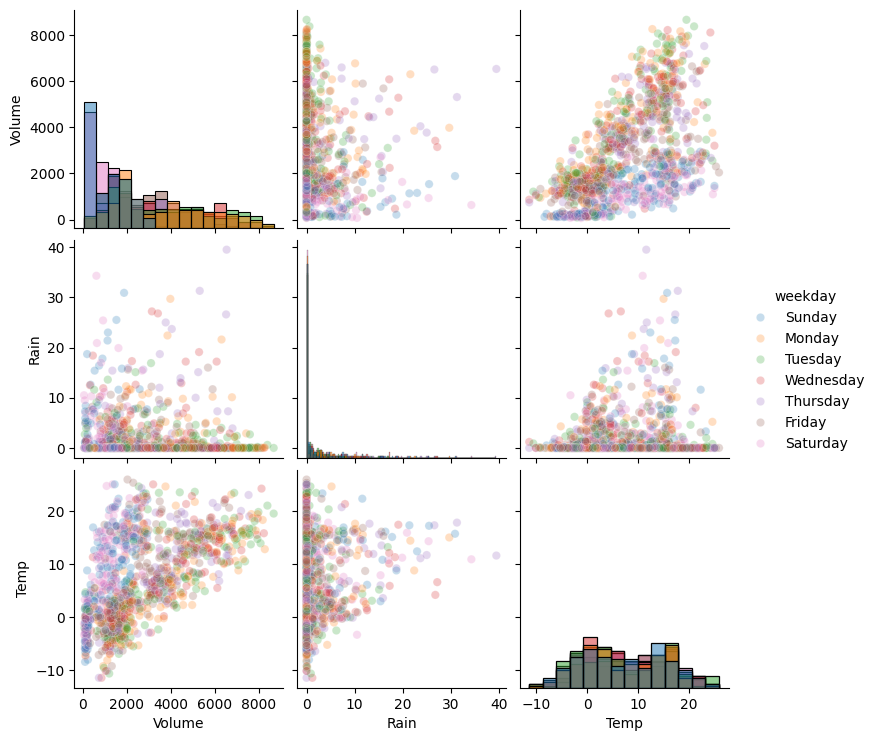

In [30]:
sns.pairplot(                                                        # Utworzenie macierzy wykresów zależności między zmiennymi
    full_years[['Volume', 'Rain', 'Temp', 'weekday']],               # Wybranie analizowanych kolumn
    hue='weekday',                                                    # Oznaczenie dni tygodnia różnymi kolorami
    kind='scatter',                                                   # Użycie wykresów punktowych poza przekątną
    diag_kind='hist',                                                 # Wyświetlenie histogramów na przekątnej
    plot_kws={'alpha': 0.25}                                         # Ustawienie przezroczystości punktów
)

plt.show()                                                            # Wyświetlenie gotowej macierzy wykresów

Wykres pozwala jednocześnie sprawdzić:
- zależność liczby wypożyczeń od temperatury,
- zależność liczby wypożyczeń od opadów,
- zależność między temperaturą i opadami,
- czy zależności różnią się w zależności od dnia tygodnia.
    
alpha=0.25 zwiększa przezroczystość punktów, dzięki czemu obszary z dużą liczbą nakładających się obserwacji są łatwiejsze do zauważenia.

Korelacja pomiędzy temperaturą a liczbą wypożyczonych rowerów jest jasna. Taka sytuacja nie zachodzi dla opadów deszczu – jednak zostawimy tę zmienną.